# BNN with Flax and Numpyro

Code from [PyData Berlin 2025: Introduction to Stochastic Variational Inference with NumPyro](https://juanitorduz.github.io/intro_svi/)

In [1]:
from jaxtyping import Array, ArrayLike, Float, Int
from flax import nnx
import jax.random as jr, jax.numpy as jnp, jax
from itertools import pairwise

import numpyro
from numpyro.contrib.module import random_nnx_module
from numpyro.infer import SVI, Predictive, Trace_ELBO
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer.svi import SVIRunResult, SVIState
import numpyro.distributions as dist

import optax
import tqdm

import matplotlib.pyplot as plt

rng_key = jr.key(1)

/Users/aaron/Documents/masters/gpkan/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data setup

In [2]:
def normalize(val, mean=None, std=None):
    """Normalize data to zero mean, unit variance"""
    if mean is None and std is None:
        # Only use training data to estimate mean and std.
        std = jnp.std(val, 0, keepdims=True)
        std = jnp.where(std == 0, 1.0, std)
        mean = jnp.mean(val, 0, keepdims=True)
    return (val - mean) / std, mean, std

In [3]:
def trig(x, y):
    assert jnp.all((0 <= x) & (x <= 5)) and jnp.all((0 <= y) & (y <= 5)), (
        "x and y must be in the range [0, 5]"
    )
    return jnp.sin(x) ** 10 + jnp.cos(10 + y * x) * jnp.cos(x)  # JVDP

In [4]:
from gpkanmodel.test_functions import goldstein_price
from sklearn.model_selection import train_test_split

n_datapts = 40
f = lambda x1, x2: goldstein_price(x1, x2)
x1, x2 = jnp.meshgrid(jnp.linspace(-2, 2, n_datapts), jnp.linspace(-2 , 2, n_datapts))
X = jnp.stack([x1.flatten(), x2.flatten()]).T
y = f(X[:, 0], X[:, 1]).reshape(-1, 1)

# f = lambda x1, x2: (x1, x2)
# x1, x2 = jnp.meshgrid(jnp.linspace(0, 5, n_datapts), jnp.linspace(0, 5, n_datapts))
# X = jnp.stack([x1.flatten(), x2.flatten()]).T
# y = f(X[:, 0], X[:, 1]).reshape(-1, 1) 

seed = 1
X_train_all, X_test, y_train_all, y_test = train_test_split(
    X, 
    y, 
    test_size=0.3,
    random_state=seed
)

X_train_sd, X_train_mean, X_train_std = normalize(X_train_all)
y_train_sd, y_train_mean, y_train_std = normalize(y_train_all)

X_test_sd, _, _ = normalize(X_test, X_train_mean, X_train_std)
y_test_sd, _, _ = normalize(y_test, y_train_mean, y_train_std)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_sd, 
    y_train_sd, 
    test_size=0.3,
    random_state=seed
)

n_train = X_train.shape[0]
n_val = X_val.shape[0]
n_test = X_test.shape[0]
n = n_train + n_val + n_test

print("Dataset sizes:")
print(f"  Training: {n_train} samples ({n_train / n:.1%})")
print(f"  Validation: {n_val} samples ({n_val / n:.1%})")
print(f"  Test: {n_test} samples ({n_test / n:.1%})")

Dataset sizes:
  Training: 784 samples (49.0%)
  Validation: 336 samples (21.0%)
  Test: 480 samples (30.0%)


## Model setup

In [5]:
class MLP(nnx.Module):
    def __init__(
        self, din: int, dout: int, hidden_layers: list[int], *, rngs: nnx.Rngs
    ) -> None:
        self.layers = nnx.List([])
        layer_dims = [din, *hidden_layers, dout]
        for in_dim, out_dim in pairwise(layer_dims):
            self.layers.append(nnx.Linear(in_dim, out_dim, rngs=rngs))

    def __call__(self, x: jax.Array) -> jax.Array:
        for layer in self.layers[:-1]:
            x = jax.nn.tanh(layer(x))

        return self.layers[-1](x)

In [6]:
nnx_module = MLP(din=2, dout=1, hidden_layers=[16, 16], rngs=nnx.Rngs(0))

AttributeError: 'List' object has no attribute 'append'

In [ ]:
def model(
    x: Float[Array, "n_obs features"], y: Int[Array, "n_obs"] | None = None
) -> None:
    """
    NumPyro model function defining the Bayesian Neural Network.

    This function specifies the generative process:
    1. Sample neural network parameters from priors
    2. Compute predictions via forward pass
    3. Sample observations from Bernoulli likelihood

    Parameters
    ----------
    x : Float[Array, "n_obs features"]
        Input features of shape (n_obs, 2)
    y : Int[Array, " n_obs"] or None, optional
        Target labels of shape (n_obs,). None during prediction.
    """
    n_obs: int = x.shape[0]  # Number of observations

    # Prior distribution factory for network parameters.
    def prior(name, shape):
        if "bias" in name:
            return dist.Normal(loc=0, scale=1)
        return dist.SoftLaplace(loc=0, scale=1)

    # Create a NumPyro-wrapped version of our neural network
    # This automatically assigns priors to all parameters
    nn = random_nnx_module(
        "nn",  # Name prefix for all parameters
        nnx_module,  # Our Flax NNX module
        prior=prior,  # Prior distribution factory
    )
    loc_y = numpyro.deterministic("mean", nn(x).squeeze(-1))    
    prec_obs = numpyro.sample("prec_obs", dist.Gamma(3.0, 1.0)) # prior on obs?
    sigma_obs = 1.0 / jnp.sqrt(prec_obs)

    with numpyro.plate("data", n_obs):
        numpyro.sample("Y", dist.Normal(loc_y, sigma_obs), obs=y)
        # numpyro.sample("Y", dist.Normal(loc_y, sigma_obs).to_event(1), obs=y)

In [ ]:
guide = AutoNormal(model)
optimizer = numpyro.optim.Adam(step_size=0.01)
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())
n_samples = 5000
rng_key, rng_subkey = jr.split(key=rng_key)
svi_result = svi.run(rng_subkey, n_samples, X_train, y_train.squeeze())

NameError: name 'nnx_module' is not defined

In [ ]:
params = svi_result.params

# Create posterior predictive sampler for training data
train_posterior_predictive = Predictive(
    model=model,  # Our BNN model
    guide=guide,  # Our trained variational guide
    params=params,  # Optimized variational parameters
    num_samples=5000,  # Number of posterior samples to draw
    return_sites=["Y"],  # Return both probabilities and predictions
)

# Generate samples for training data
rng_key, rng_subkey = jr.split(key=rng_key)
train_posterior_predictive_samples = train_posterior_predictive(rng_subkey, X_train)
y_pred = train_posterior_predictive_samples["Y"]
mu_y = y_pred.mean(0)

In [ ]:
jnp.sum((mu_y - y_train.squeeze())**2)/mu_y.shape[0]

Array(0.0048291, dtype=float32)

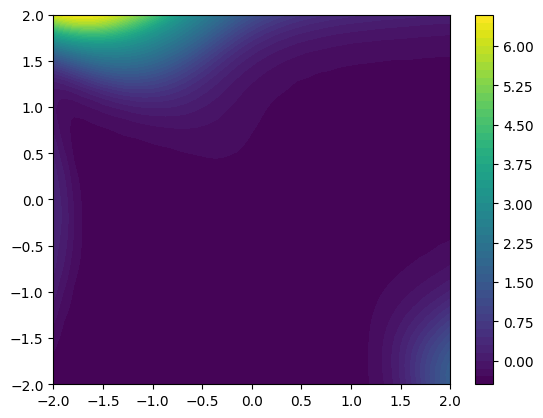

In [ ]:
X_std, _, _  = normalize(X, X_train_mean, X_train_std)
whole_posterior_pred_samples = train_posterior_predictive(rng_subkey, X_std)
mu_hat = whole_posterior_pred_samples["Y"].mean(0)
plt.contourf(x1, x2, mu_hat.reshape(40, 40), levels=50)
plt.colorbar()
plt.show()

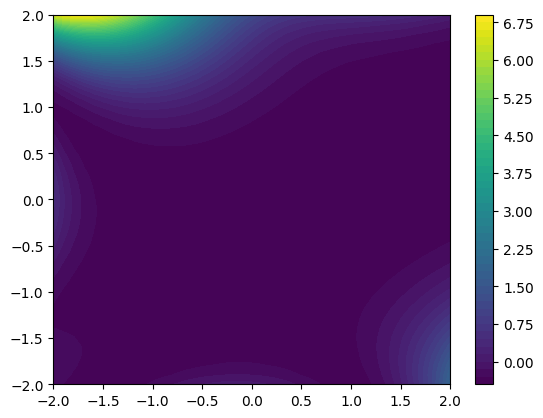

In [ ]:
y_std, _, _  = normalize(y, y_train_mean, y_train_std)
plt.contourf(x1, x2, y_std.reshape(40, 40), levels=50)
plt.colorbar()
plt.show()

## Explicit training loop

In [ ]:
# scheduler = optax.linear_onecycle_schedule(
#     transition_steps=8_000,  # Total number of optimization steps
#     peak_value=0.008,  # Maximum learning rate (reached at pct_start)
#     pct_start=0.2,  # Percent of training to reach peak (20%)
#     pct_final=0.8,  # Percent of training for final phase (80%)
#     div_factor=3,  # Initial LR = peak_value / div_factor
#     final_div_factor=4,  # Final LR = initial_LR / final_div_factor
# )

# optimizer = optax.chain(
#     # Primary optimizer: Adam with scheduled learning rate
#     optax.adam(learning_rate=scheduler),
#     # Secondary optimizer: Reduce LR when loss plateaus
#     optax.contrib.reduce_on_plateau(
#         factor=0.1,  # Multiply LR by 0.1 when plateau detected
#         patience=10,  # Wait 10 evaluations before reducing
#         accumulation_size=100,  # Window size for detecting plateaus
#     ),
# )

optimizer = numpyro.optim.Adam(step_size=0.01)

svi = SVI(
    model=model,  # Our BNN model
    guide=guide,  # Our variational approximation
    optim=optimizer,  # Optimization algorithm
    loss=Trace_ELBO(),  # ELBO loss function
)

# Initialize SVI state with random parameters
rng_key, rng_subkey = jr.split(key=rng_key)
svi_state = svi.init(rng_subkey, x=X_train, y=y_train)

In [ ]:
@jax.jit
def body_fn(svi_state: SVIState, _) -> tuple[SVIState, jax.Array]:
    """
    Single training step: compute gradients and update parameters.

    Parameters
    ----------
    svi_state : numpyro.infer.svi.SVIState
        Current SVI state containing parameters and optimizer state
    _ : Any
        Unused (for scan compatibility)

    Returns
    -------
    tuple
        Updated SVI state and training loss
    """
    svi_state, loss = svi.update(svi_state, x=X_train, y=y_train.squeeze())
    return svi_state, loss

def get_val_loss(
    svi_state: SVIState,
    x_val: Float[Array, "n_val features"],
    y_val: Int[Array, "n_val"],
) -> jax.Array:
    """
    Compute validation loss without updating parameters.

    Parameters
    ----------
    svi_state : numpyro.infer.svi.SVIState
        Current SVI state
    x_val : Float[Array, "n_val features"]
        Validation features
    y_val : Int[Array, " n_val"]
        Validation labels

    Returns
    -------
    jax.Array
        Validation ELBO loss
    """
    _, rng_subkey = jr.split(svi_state.rng_key)
    params = svi.get_params(svi_state)  # Extract current parameter values

    # Compute loss without gradients or parameter updates
    return svi.loss.loss(
        rng_subkey,
        params,  # Current parameter values
        svi.model,  # Model function
        svi.guide,  # Guide function
        x=x_val,
        y=y_val.squeeze(),
    )

In [ ]:
num_steps = 8_000  # Maximum number of training steps
patience = 1000  # Early stopping patience (steps)

# Storage for loss tracking
train_losses = []  # Raw training losses
norm_train_losses = []  # Training losses normalized by dataset size
val_losses = []  # Raw validation losses
norm_val_losses = []  # Validation losses normalized by dataset size

print("Starting SVI training...")
print(f"Max steps: {num_steps}")
print(f"Early stopping patience: {patience}")
print(f"Training set size: {n_train}")
print(f"Validation set size: {n_val}")

# Main training loop with progress bar
with tqdm.trange(1, num_steps + 1) as t:
    batch = max(num_steps // 20, 1)  # Batch size for progress updates
    patience_counter = 0  # Counter for early stopping

    for i in t:
        # Perform one training step (JIT compiled for speed)
        svi_state, train_loss = body_fn(svi_state, None)

        # Normalize loss by dataset size for fair comparison
        norm_train_loss = jax.device_get(train_loss) / y_train.shape[0]
        train_losses.append(jax.device_get(train_loss))
        norm_train_losses.append(norm_train_loss)

        # Compute validation loss (JIT compiled for speed)
        val_loss = jax.jit(get_val_loss)(svi_state, X_val, y_val)
        norm_val_loss = jax.device_get(val_loss) / y_val.shape[0]
        val_losses.append(jax.device_get(val_loss))
        norm_val_losses.append(norm_val_loss)

        # Early stopping logic: stop if validation loss > training loss consistently
        condition = norm_val_loss > norm_train_loss
        patience_counter = patience_counter + 1 if condition else 0

        if patience_counter >= patience:
            print(
                f"Early stopping at step {i} (validation loss exceeding training loss)"
            )
            break

        # Update progress bar with recent average losses
        if i % batch == 0:
            avg_train_loss = sum(train_losses[i - batch :]) / batch
            avg_val_loss = sum(val_losses[i - batch :]) / batch

            t.set_postfix_str(
                f"train: {avg_train_loss:.4f}, val: {avg_val_loss:.4f}",
                refresh=False,
            )

# Convert loss lists to JAX arrays for efficient computation
train_losses = jnp.stack(train_losses)
val_losses = jnp.stack(val_losses)

# Create result object containing final parameters and training history
svi_result = SVIRunResult(
    params=svi.get_params(svi_state),  # Final optimized parameters
    state=svi_state,  # Final SVI state
    losses=train_losses,  # Training loss history
)

print(f"\nTraining completed after {len(train_losses)} steps")
print(f"Final training loss: {train_losses[-1]:.4f}")
print(f"Final validation loss: {val_losses[-1]:.4f}")

Starting SVI training...
Max steps: 8000
Early stopping patience: 1000
Training set size: 784
Validation set size: 336


 12%|█▎        | 1000/8000 [00:01<00:11, 622.37it/s, train: 1111.4146, val: 850.6000]


Early stopping at step 1001 (validation loss exceeding training loss)

Training completed after 1001 steps
Final training loss: 688.6607
Final validation loss: 681.3894


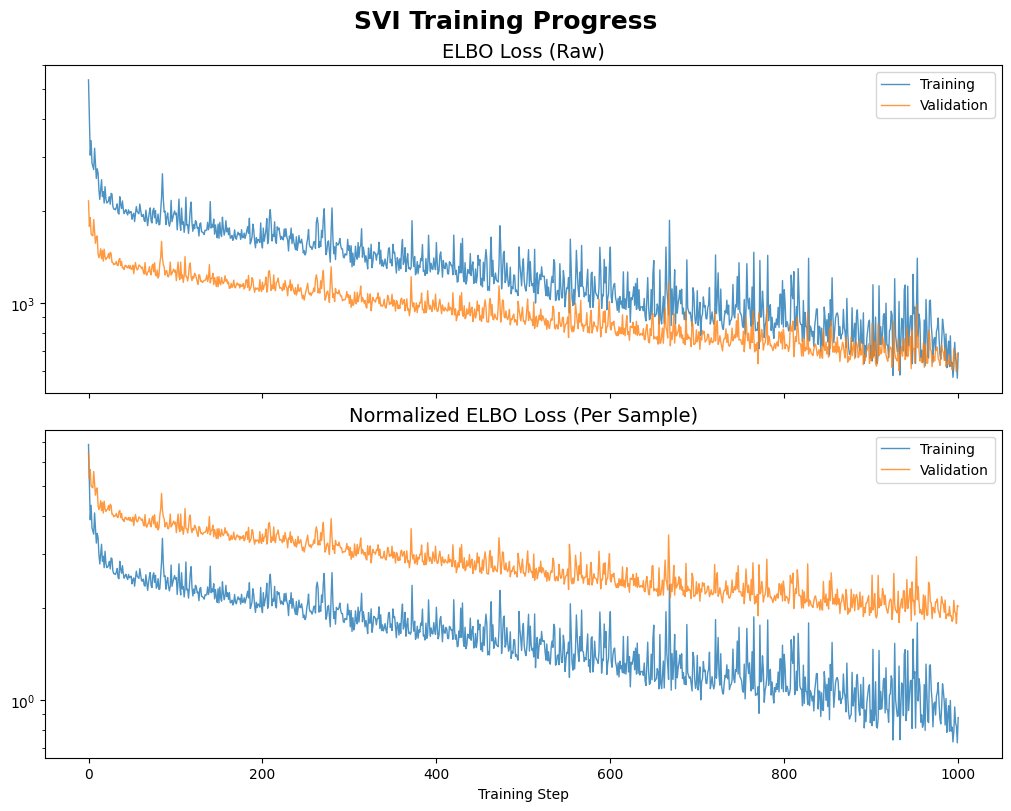

In [ ]:
fig, ax = plt.subplots(
    nrows=2, ncols=1, figsize=(10, 8), sharex=True, sharey=False, layout="constrained"
)

ax[0].plot(train_losses, c="C0", linewidth=1, alpha=0.8, label="Training")
ax[0].plot(val_losses, c="C1", linewidth=1, alpha=0.8, label="Validation")
ax[0].legend(loc="upper right")
ax[0].set(yscale="log")
ax[0].set_title("ELBO Loss (Raw)", fontsize=14)

ax[1].plot(norm_train_losses, c="C0", linewidth=1, alpha=0.8, label="Training")
ax[1].plot(norm_val_losses, c="C1", linewidth=1, alpha=0.8, label="Validation")
ax[1].legend(loc="upper right")
ax[1].set(yscale="log")
ax[1].set_xlabel("Training Step")
ax[1].set_title("Normalized ELBO Loss (Per Sample)", fontsize=14)

plt.suptitle("SVI Training Progress", fontsize=18, fontweight="bold");

In [ ]:
params = svi_result.params

# Create posterior predictive sampler for training data
train_posterior_predictive = Predictive(
    model=model,  # Our BNN model
    guide=guide,  # Our trained variational guide
    params=params,  # Optimized variational parameters
    num_samples=5000,  # Number of posterior samples to draw
    return_sites=["Y"],  # Return both probabilities and predictions
)

# Generate samples for training data
rng_key, rng_subkey = jr.split(key=rng_key)
train_posterior_predictive_samples = train_posterior_predictive(rng_subkey, X_train)
train_posterior_predictive_samples["Y"].shape

(5000, 784)

In [ ]:
jnp.sum((train_posterior_predictive_samples["Y"].mean(0) - y_train.squeeze())**2)/mu_y.shape[0]

Array(0.02593372, dtype=float32)

In [ ]:
rng_key, rng_subkey = jr.split(key=rng_key)
X_std, _, _  = normalize(X, X_train_mean, X_train_std)
whole_posterior_pred_samples = train_posterior_predictive(rng_subkey, X_std)

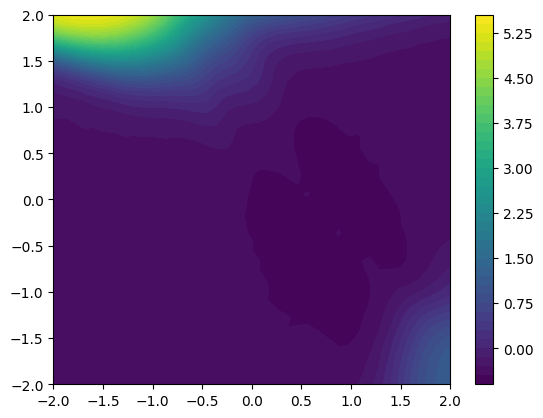

In [ ]:
mu_hat = whole_posterior_pred_samples["Y"].mean(0)
plt.contourf(x1, x2, mu_hat.reshape(40, 40), levels=50)
plt.colorbar()
plt.show()